# Action-Angle Coordinates: Inverse Transformations (Staeckel)

The `actionAngleStaeckelInverse` class performs the **inverse**
transformation for axisymmetric Staeckel potentials: given actions and
angles, it computes phase-space coordinates $(\mathbf{x}, \mathbf{v})$.
Each orbital torus is the product of its two librations in the prolate
spheroidal coordinates of the potential's focal length; both are sampled
exactly and mapped onto the torus with the same actions of an auxiliary
isochrone potential by canonical point transformations, and the map is
exactly symplectic, so the orbits it returns are exact orbits of a
Hamiltonian close to the potential's (the potential's own at the tori it
was set up on). Set up on a grid of tori, it interpolates between them.
While the construction of `actionAngleStaeckelInverse` uses an auxiliary
isochrone potential like Binney & Co.'s TorusMapper, the underlying method
is entirely different; full details to be written up (Bovy in prep.).

The potential must be of Staeckel form and supply its focal length (an
`OblateStaeckelWrapperPotential` or an exact Staeckel potential such as
`KuzminKutuzovStaeckelPotential`); a general axisymmetric potential can be
given together with `delta=`, which wraps it in its Staeckel
approximation, the same model that the forward `actionAngleStaeckel` uses.

This is useful for:
- Setting up initial conditions with specific actions
- Computing orbital tori
- Mapping the orbital building blocks of axisymmetric systems

For the forward transformation in axisymmetric potentials, see
[Staeckel Approximation](staeckel.ipynb); for the inverse transformation
in spherical potentials, see [Inverse Transformations (spherical)](spherical_inverse.ipynb);
for an alternative inverse transformation in axisymmetric potentials, see the
[Torus Mapper](torus.ipynb).

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import KuzminKutuzovStaeckelPotential
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Setup

We use a Kuzmin-Kutuzov potential, an exact Staeckel potential, normalized
such that the circular velocity is one at $R = 1$, with an axis ratio of
four and a focal length of $1.4$. With `setup_interp=True`,
`actionAngleStaeckelInverse` sets up a grid of tori: their angular momenta
span those of the circular orbits between `Rmin` and `Rmax`, their energies
run from each circular orbit's up to that of the planar orbit with
apocenter `Rinf`, and their third integrals run from the planar orbit's
($J_z = 0$) to the shell orbit's ($J_R = 0$). The most demanding tori of
this grid need more than the default 32 harmonics of the anomaly maps to
be resolved (the constructor warns when they are not), so we raise
`mm_npt`:

In [2]:
from galpy.actionAngle import actionAngleStaeckelInverse

kkp = KuzminKutuzovStaeckelPotential(normalize=1.0, ac=4.0, Delta=1.4)
aASI = actionAngleStaeckelInverse(
    pot=kkp,
    setup_interp=True,
    Rmin=0.5,
    Rmax=1.5,
    Rinf=3.5,
    nE=8,
    nLz=8,
    nI3=8,
    mm_npt=48,
)

The auxiliary isochrone potential, fitted to the rotation curve of the
potential in the plane over the radial range of the grid, is available as
the `auxiliary` attribute (an `IsochronePotential`); one can also be given
with the `auxiliary=` keyword:

In [3]:
print(
    f"Auxiliary isochrone: amp = {aASI.auxiliary._amp:.3f}, b = {aASI.auxiliary.b:.3f}"
)

Auxiliary isochrone: amp = 11.239, b = 1.182


## Computing frequencies

The `Freqs` method returns the radial, azimuthal, and vertical frequencies
of the torus with actions $(J_R, L_z, J_z)$:

In [4]:
jr_val, lz_val, jz_val = 0.05, 1.0, 0.05
Om = aASI.Freqs(jr_val, lz_val, jz_val)
print(f"Omega_R = {Om[0]:.6f}, Omega_phi = {Om[1]:.6f}, Omega_z = {Om[2]:.6f}")

Omega_R = 1.654456, Omega_phi = 0.936122, Omega_z = 1.701313


## Computing an orbit from action-angle coordinates

Advancing the angles linearly in time at the torus's frequencies traces
the orbit. Calling the object with the actions and the angles returns
$(R, v_R, v_T, z, v_z, \phi)$:

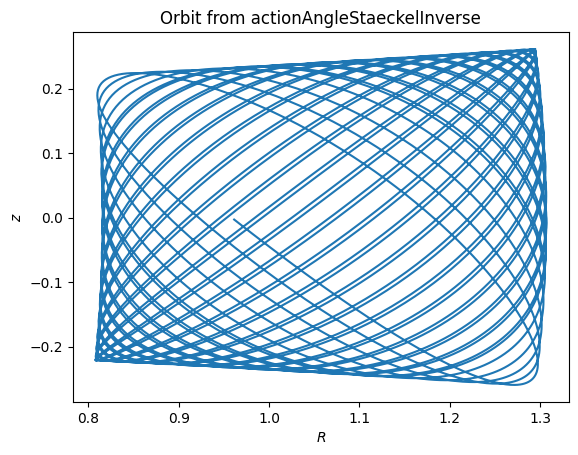

In [5]:
times = numpy.linspace(0.0, 100.0, 10001)
init_angle = numpy.array([1.0, 2.0, 3.0])
angles = numpy.tile(init_angle, (len(times), 1)) + Om[:3] * numpy.tile(times, (3, 1)).T

R, vR, vT, z, vz, phi = aASI(
    jr_val, lz_val, jz_val, angles[:, 0], angles[:, 1], angles[:, 2]
)

plt.plot(R, z)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Orbit from actionAngleStaeckelInverse");

### Comparison with direct orbit integration

Integrating an orbit from the first point of the torus and comparing:

Maximum distance between the torus and the integrated orbit: 4.6e-05


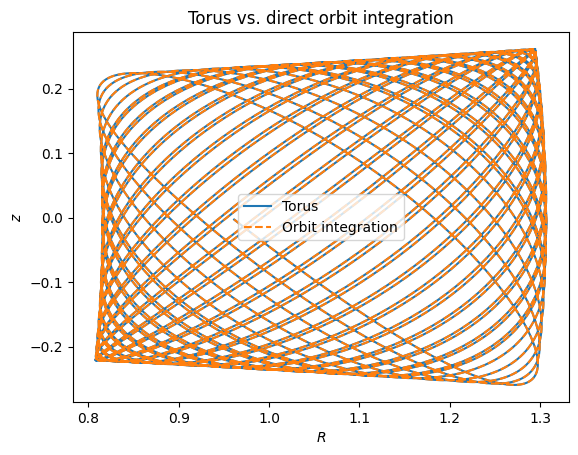

In [6]:
orb = Orbit([R[0], vR[0], vT[0], z[0], vz[0], phi[0]])
orb.integrate(times, kkp)

plt.plot(R, z, label="Torus")
plt.plot(orb.R(times), orb.z(times), "--", label="Orbit integration")
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.legend()
plt.title("Torus vs. direct orbit integration")
sep = numpy.sqrt(
    (R * numpy.cos(phi) - orb.x(times)) ** 2
    + (R * numpy.sin(phi) - orb.y(times)) ** 2
    + (z - orb.z(times)) ** 2
)
print(
    f"Maximum distance between the torus and the integrated orbit: {numpy.amax(sep):.1e}"
)

The two orbits are the same to the accuracy with which the family
interpolates between its grid tori (the maximum distance printed above);
for a torus of the grid itself, the agreement is limited by the orbit
integrator instead. The energy tells the two apart: along the torus it is
constant to the family's interpolation error, the same at all times, while
along the integrated orbit it drifts with the accumulated integration
error:

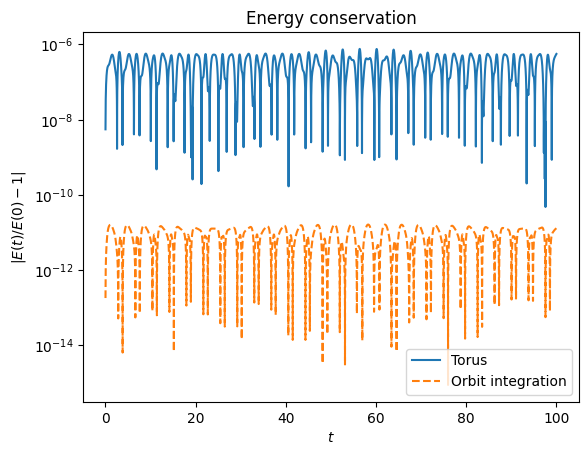

In [7]:
from galpy.potential import evaluatePotentials

E_torus = 0.5 * (vR**2 + vT**2 + vz**2) + evaluatePotentials(kkp, R, z)
E_orbit = orb.E(times, pot=kkp)
plt.semilogy(times[1:], numpy.fabs(E_torus[1:] / E_torus[0] - 1.0), label="Torus")
plt.semilogy(
    times[1:],
    numpy.fabs(E_orbit[1:] / E_orbit[0] - 1.0),
    "--",
    label="Orbit integration",
)
plt.xlabel(r"$t$")
plt.ylabel(r"$|E(t)/E(0) - 1|$")
plt.legend()
plt.title("Energy conservation");

## The xvFreqs method

`xvFreqs` returns the phase-space coordinates and the frequencies at once:

In [8]:
angler = numpy.linspace(0.0, 2.0 * numpy.pi, 101)
anglephi = numpy.zeros(101)
anglez = numpy.zeros(101)

R, vR, vT, z, vz, phi, OR, Op, Oz = aASI.xvFreqs(
    jr_val, lz_val, jz_val, angler, anglephi, anglez
)

print(f"Omega_R = {OR:.6f}, Omega_phi = {Op:.6f}, Omega_z = {Oz:.6f}")

Omega_R = 1.654456, Omega_phi = 0.936122, Omega_z = 1.701313


## Orbital torus cross-sections

By varying one angle while holding the others fixed, we can visualize
cross-sections of the orbital torus, along the radial angle and along the
vertical angle:

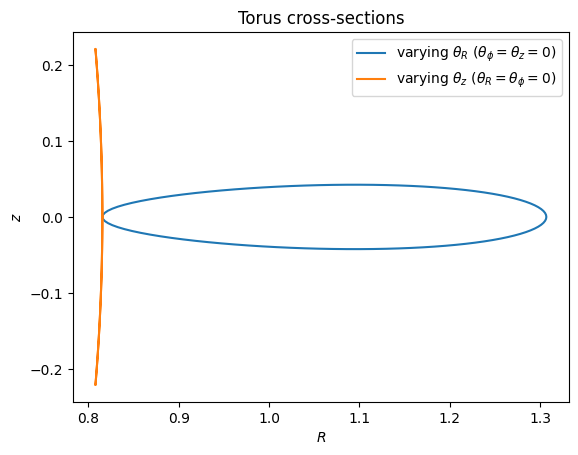

In [9]:
Rz, vRz, vTz, zz, vzz, phiz = aASI(jr_val, lz_val, jz_val, anglez, anglephi, angler)
plt.plot(R, z, label=r"varying $\theta_R$ ($\theta_\phi = \theta_z = 0$)")
plt.plot(Rz, zz, label=r"varying $\theta_z$ ($\theta_R = \theta_\phi = 0$)")
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.legend()
plt.title("Torus cross-sections");

## Mapping a full torus

Sampling the three angles uniformly in $[0, 2\pi]$ maps the entire orbital
torus and shows directly where the orbit spends most of its time:

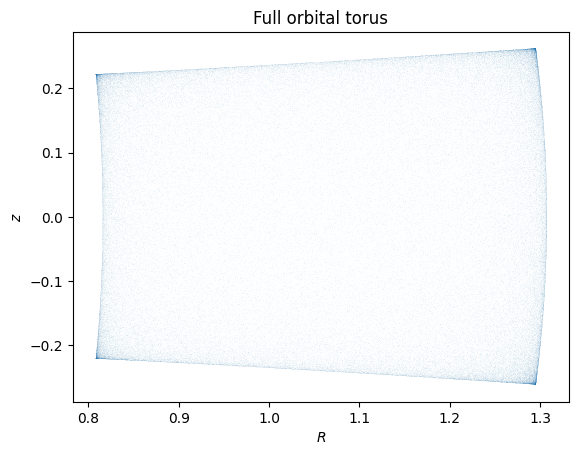

In [10]:
numpy.random.seed(1)
nangles = 200001
angler_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
anglep_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
anglez_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi

R_torus, _, _, z_torus, _, _ = aASI(
    jr_val, lz_val, jz_val, angler_rand, anglep_rand, anglez_rand
)

plt.plot(R_torus, z_torus, ",", alpha=0.02)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Full orbital torus");

## Tori at the edges: planar and shell orbits

A torus with $J_z = 0$ is a planar orbit, a one-dimensional libration in
$R$, and the planar tori at a given $L_z$ form nested loops in the
$(R, v_R)$ plane with the circular orbit, $J_R = J_z = 0$, at their
center; a torus with $J_R = 0$ is a shell orbit, a libration on a
spheroid, and the shell tori at a given $L_z$ form nested loops in the
$(z, v_z)$ plane through the midplane. Both edges of the family are
reached continuously, and the edge tori themselves evaluate exactly:

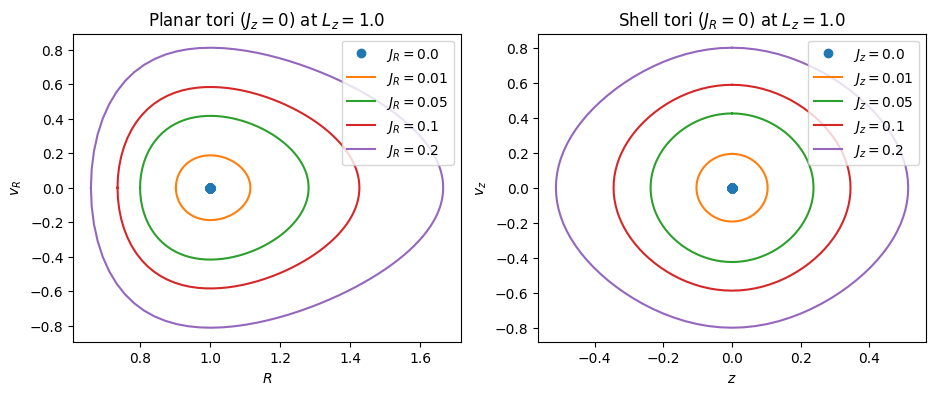

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for jr in [0.0, 0.01, 0.05, 0.1, 0.2]:
    R, vR, vT, z, vz, phi = aASI(jr, lz_val, 0.0, angler, 0.0, 0.0)
    ax[0].plot(R, vR, "o" if jr == 0.0 else "-", label=rf"$J_R = {jr}$")
ax[0].set_xlabel(r"$R$")
ax[0].set_ylabel(r"$v_R$")
ax[0].legend()
ax[0].set_title(rf"Planar tori ($J_z = 0$) at $L_z = {lz_val}$")
for jz in [0.0, 0.01, 0.05, 0.1, 0.2]:
    R, vR, vT, z, vz, phi = aASI(0.0, lz_val, jz, 0.0, 0.0, angler)
    ax[1].plot(z, vz, "o" if jz == 0.0 else "-", label=rf"$J_z = {jz}$")
ax[1].set_xlabel(r"$z$")
ax[1].set_ylabel(r"$v_z$")
ax[1].legend()
ax[1].set_title(rf"Shell tori ($J_R = 0$) at $L_z = {lz_val}$");

## Specifying a torus by its integrals

A torus can also be specified by its integrals of motion $(E, L_z, I_3)$,
using the `JR` and `Jz` methods to obtain its actions. The third integral
is that of the separated momentum, $p_u^2 = 2\Delta^2[E\sinh^2 u - U(u) -
I_3] - L_z^2/\sinh^2 u$ in the gauge $V(\pi/2) = 0$, which can be
evaluated for any phase-space point in the prolate spheroidal coordinates
of the potential's focal length:

In [12]:
from galpy.util import coords


def integrals(pot, delta, R, vR, vT, z, vz):
    # (E, L_z, I_3) of a phase-space point in a Staeckel potential
    E = 0.5 * (vR**2 + vT**2 + vz**2) + evaluatePotentials(pot, R, z)
    Lz = R * vT
    u, v = coords.Rz_to_uv(R, z, delta=delta)
    pu = delta * (vR * numpy.cosh(u) * numpy.sin(v) + vz * numpy.sinh(u) * numpy.cos(v))
    U = evaluatePotentials(pot, delta * numpy.sinh(u), 0.0) * numpy.cosh(u) ** 2
    I3 = (
        E * numpy.sinh(u) ** 2
        - U
        - (pu**2 + Lz**2 / numpy.sinh(u) ** 2) / (2.0 * delta**2)
    )
    return E, Lz, I3


E_val, Lz_val, I3_val = integrals(kkp, 1.4, 1.0, 0.2, 1.0, 0.15, 0.2)
jr_I, jz_I = aASI.JR(E_val, Lz_val, I3_val), aASI.Jz(E_val, Lz_val, I3_val)
print(
    f"J_R = {jr_I:.6f}, J_z = {jz_I:.6f} for E = {E_val:.4f}, L_z = {Lz_val:.2f}, I_3 = {I3_val:.4f}"
)
R, vR, vT, z, vz, phi = aASI(jr_I, Lz_val, jz_I, angler, 0.0, 0.0)
E_check = 0.5 * (vR**2 + vT**2 + vz**2) + evaluatePotentials(kkp, R, z)
print(f"Energy along the torus: {numpy.mean(E_check):.6f} +/- {numpy.std(E_check):.1e}")

J_R = 0.012797, J_z = 0.030611 for E = -3.1476, L_z = 1.00, I_3 = 3.4884
Energy along the torus: -3.147579 +/- 7.7e-07


## Checking against the forward transformation

The forward transformation `actionAngleStaeckel` computes actions,
frequencies, and angles from phase-space coordinates by direct quadrature,
independently of the inverse. Sending the points of a torus through it
recovers the actions and angles they were computed from. For the torus
used above, which lies between the tori of the grid, the recovered actions
and angles differ by the family's interpolation error; a torus that is set
up on its own, with `setup_interp=False` and its integrals given in `Es`,
`Lzs` and `I3s`, is reproduced to the accuracy of the forward
transformation itself:

In [13]:
from galpy.actionAngle import actionAngleStaeckel

aAS = actionAngleStaeckel(pot=kkp, delta=1.4, c=True, order=100)


def roundtrip(aASI, jr, lz, jz):
    angler = numpy.linspace(0.0, 2.0 * numpy.pi, 51)
    anglephi, anglez = 0.3 + 1.7 * angler, 0.7 + 2.3 * angler
    out = aASI(jr, lz, jz, angler, anglephi, anglez)
    jr_f, lz_f, jz_f, _, _, _, ar_f, ap_f, az_f = aAS.actionsFreqsAngles(*out)
    wrap = lambda d: (d + numpy.pi) % (2.0 * numpy.pi) - numpy.pi
    return (
        (numpy.amax(numpy.fabs(jr_f - jr)) + numpy.amax(numpy.fabs(jz_f - jz)))
        / (jr + jz),
        max(
            numpy.amax(numpy.fabs(wrap(ar_f - angler))),
            numpy.amax(numpy.fabs(wrap(ap_f - anglephi))),
            numpy.amax(numpy.fabs(wrap(az_f - anglez))),
        ),
    )


dJ, dth = roundtrip(aASI, jr_I, Lz_val, jz_I)
print(
    f"Interpolated family: relative error in the actions = {dJ:.1e}, error in the angles = {dth:.1e}"
)

aASI_single = actionAngleStaeckelInverse(
    pot=kkp, Es=[E_val], Lzs=[Lz_val], I3s=[I3_val], mm_npt=48
)
dJ, dth = roundtrip(
    aASI_single,
    aASI_single.JR(E_val, Lz_val, I3_val),
    Lz_val,
    aASI_single.Jz(E_val, Lz_val, I3_val),
)
print(
    f"Single torus: relative error in the actions = {dJ:.1e}, error in the angles = {dth:.1e}"
)

Interpolated family: relative error in the actions = 1.9e-05, error in the angles = 3.7e-05


Single torus: relative error in the actions = 1.8e-12, error in the angles = 2.8e-11


## A realistic potential in the Staeckel approximation

Any axisymmetric potential can be used through its Staeckel approximation
by giving the focal length with `delta=`, which wraps the potential in an
`OblateStaeckelWrapperPotential`; the tori are then those of that
Staeckel model of the potential. For a disk potential the vertical
libration crosses the thin disk, and the map of that libration needs many
harmonics to be resolved (the constructor warns when they are not), so we
set up a single torus of `MWPotential2014` with `mm_npt=256`. Traversed at
its frequencies, the torus follows an orbit integrated in the Staeckel
model exactly, and an orbit integrated in `MWPotential2014` itself to the
accuracy of the Staeckel approximation:

J_R = 0.00474, J_z = 0.01185; Omega_R = 1.28805, Omega_phi = 0.95346, Omega_z = 1.68457


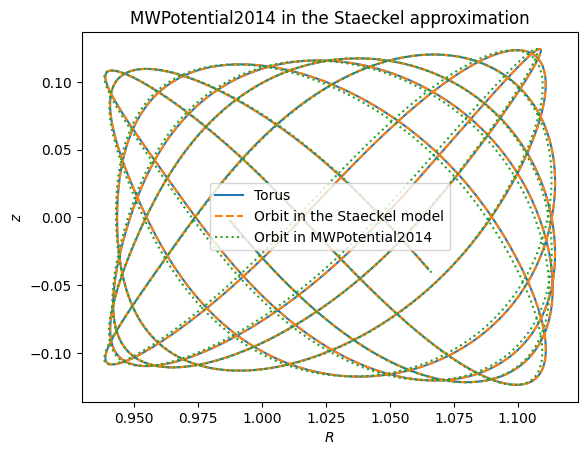

In [14]:
from galpy.potential import MWPotential2014, OblateStaeckelWrapperPotential

delta = 0.45
mwsp = OblateStaeckelWrapperPotential(pot=MWPotential2014, delta=delta)
E_mw, Lz_mw, I3_mw = integrals(mwsp, delta, 1.0, 0.1, 1.0, 0.1, 0.1)
aASI_mw = actionAngleStaeckelInverse(
    pot=MWPotential2014, delta=delta, Es=[E_mw], Lzs=[Lz_mw], I3s=[I3_mw], mm_npt=256
)
jr_mw, jz_mw = aASI_mw.JR(E_mw, Lz_mw, I3_mw), aASI_mw.Jz(E_mw, Lz_mw, I3_mw)
Om_mw = aASI_mw.Freqs(jr_mw, Lz_mw, jz_mw)
print(
    f"J_R = {jr_mw:.5f}, J_z = {jz_mw:.5f}; Omega_R = {Om_mw[0]:.5f}, Omega_phi = {Om_mw[1]:.5f}, Omega_z = {Om_mw[2]:.5f}"
)
ts = numpy.linspace(0.0, 30.0, 3001)
R, vR, vT, z, vz, phi = aASI_mw(
    jr_mw, Lz_mw, jz_mw, 1.0 + Om_mw[0] * ts, 2.0 + Om_mw[1] * ts, 3.0 + Om_mw[2] * ts
)
orb_sp = Orbit([R[0], vR[0], vT[0], z[0], vz[0], phi[0]])
orb_sp.integrate(ts, mwsp)
orb_mw = Orbit([R[0], vR[0], vT[0], z[0], vz[0], phi[0]])
orb_mw.integrate(ts, MWPotential2014)
plt.plot(R, z, label="Torus")
plt.plot(orb_sp.R(ts), orb_sp.z(ts), "--", label="Orbit in the Staeckel model")
plt.plot(orb_mw.R(ts), orb_mw.z(ts), ":", label="Orbit in MWPotential2014")
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.legend()
plt.title("MWPotential2014 in the Staeckel approximation");

Like the other action-angle classes, `actionAngleStaeckelInverse` accepts
and returns physical units when set up with `ro=` and `vo=`. See the
action-angle API documentation for details.